## Putting it all together for Training
Pipeline: Preprocessing -> Feature extraction -> spike encoding ->training

In [1]:
from pipeline_functions import *

import numpy as np

import snntorch.spikeplot as splt
import snntorch as snn
from snntorch import functional as SF

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

#sets seed for random to 42
torch.manual_seed(42) 

# sets device for tensors and model
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


### Preprocessing

In [2]:
## preprocessing function to be inputted

preproc_ds, y = fn_preprocess.preprocess_training("C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s17_v72.mat")

150
750


(32, 307, 900)
(900,)


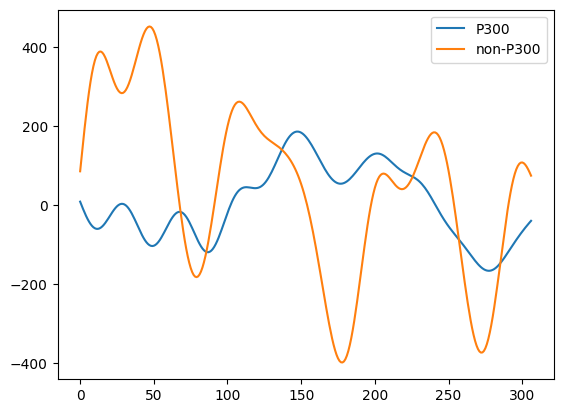

In [3]:
print(preproc_ds.shape)
print(y.shape)
avg_P300 = preproc_ds[12, :, :150].sum(axis=1)
avg_non_P300 = preproc_ds[12, :, 150:].sum(axis=1)
plt.plot(avg_P300, label='P300')
plt.plot(avg_non_P300, label='non-P300')
plt.legend()


### Feature Extraction

In [4]:
## feature extraction
X_norm, fe_X = fn_feature_extraction.extractFeatures(preproc_ds)

X shape: (900, 32, 307)
Shape after normalization: (900, 32, 307)
Features array shape: (900, 160)
Reshaped tensor for SNN input: (900, 9824)


In [5]:
# only pz electrode, uncomment to change to only have that electrode, will also have to change initial layer in module creation
# X_norm = X_norm[:, 12, :]
# print(X_norm.shape)

### Spike Encoding

This is a first place we can alter hyperparameters for results <br>
We can change:
- T_ms
- dt_ms
- r_min
- r_max

In [6]:
T_ms = 100
dt_ms = 1
r_min = 150
r_max = 300
encoded_X, r_hz = spike_encoding.deterministic_rate(X_norm, T_ms=T_ms, dt_ms=dt_ms, r_min=r_min, r_max=r_max)
print(encoded_X.shape)
print(r_hz.shape)

(900, 32, 307, 100)
(900, 32, 307)


In [7]:
print(encoded_X[1, 1, :])
print(r_hz[1, 1])
print(encoded_X.mean())

[[0 0 0 ... 1 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
[216.0817  216.4053  216.63458 216.72847 216.65111 216.37329 215.87376
 215.1402  214.16974 212.96915 211.5546  209.9511  208.19162 206.31586
 204.36893 202.39981 200.45976 198.60059 196.87296 195.3248  193.99963
 192.93515 192.16177 191.70158 191.56732 191.7617  192.27701 193.09505
 194.18752 195.5166  197.03607 198.69266 200.42766 202.17896 203.883
 205.4769  206.9007  208.0992  209.02399 209.63495 209.90154 209.8038
 209.33298 208.49178 207.29422 205.7653  203.94022 201.86328 199.58676
 197.16936 194.67447 192.16855 189.71918 187.39331 185.25542 183.36594
 181.77972 180.54488 179.7017  179.28198 179.30853 179.7949  180.74539
 182.15521 184.01074 186.2901  188.96362 191.99457 195.33984 198.95084
 202.77425 206.75299 210.82721 214.93521 219.01462 223.00346 226.84131
 230.4705  233.83737 236.89337 239.59613 241.91055 243.80948 245.27435
 246.29562 246.8727  247.01395 

### Create tensors and dataloaders from the data

Hyperparameter to tune
- batch_size

In [8]:
batch_size = 128

# in order (trials, time_steps, features) by swapping last two dimensions
encoded_X = np.moveaxis(encoded_X, source=-1, destination=1)
print(encoded_X.shape)

train_loader, val_loader, test_loader, class_weights = train.prepare_training_data(encoded_X, y, batch_size=batch_size, balanced=False)

(900, 100, 32, 307)
Train size: 630, Val size: 135, Test size: 135
Training Class Counts:  tensor([519, 111])
Training Class Weights: tensor([0.3524, 1.6476])


### Module Creation

Hyperparameters:
- hidden_layer
- betas for each LIF layer
- thresholds for each LIF layer (**important!!)

In [9]:
# determined from feature extraction
num_features = encoded_X.shape[2]  * encoded_X.shape[3]
print(num_features)

#tunable
hidden_layer = 128
betas = [0.9, 0.9]
thresholds = [1, 2.1]

snn = SNNModule.createSNN(num_features, hidden_layer=hidden_layer, betas=betas, thresholds=thresholds)

9824


### Training Hyperparameters

Tunable:
- num_epochs (for hyperparameter tuning, keep low to find other parameters optimal, then increase once found for real training)
- lr (learning rate: How fast the model changes)
- criterion: loss function to use, changed to Cross Entropy loss to calculate for membrane potential instead of spikes (hopefully more stable)
- optimizer: method to change weights, can use Adam, SGD w/ momentum, and others. Adam is usually the best but others can be checked
- weight_decay and more: there are other parameters we can change if these dont give good results

In [10]:
num_epochs = 10
lr = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(snn.parameters(), lr=lr)

update_every = 2 # will not change results, just prints updates divisible by this number

history = train.train(model=snn, num_epochs=num_epochs, train_loader=train_loader, val_loader=val_loader,
                      criterion=criterion, optimizer=optimizer, device=device, update_every=update_every, batch_first=True)

Epoch 1: Training Loss: 0.7152, Training Accuracy: 43.65%, Validation Loss: 0.6798, Validation Accuracy: 86.67%
Avg output spike rate: 0.4900
Avg output membrane max: 3.2470
Predictions for each class: tensor([135,   0])
Epoch 3: Training Loss: 0.7277, Training Accuracy: 41.43%, Validation Loss: 0.6820, Validation Accuracy: 86.67%
Avg output spike rate: 0.4900
Avg output membrane max: 3.2152
Predictions for each class: tensor([135,   0])
Epoch 5: Training Loss: 0.7251, Training Accuracy: 29.68%, Validation Loss: 0.6843, Validation Accuracy: 86.67%
Avg output spike rate: 0.4800
Avg output membrane max: 3.0706
Predictions for each class: tensor([135,   0])
Epoch 7: Training Loss: 0.7120, Training Accuracy: 69.68%, Validation Loss: 0.6814, Validation Accuracy: 86.67%
Avg output spike rate: 0.4800
Avg output membrane max: 3.1273
Predictions for each class: tensor([135,   0])
Epoch 9: Training Loss: 0.6934, Training Accuracy: 82.38%, Validation Loss: 0.6717, Validation Accuracy: 86.67%
Avg 

In [11]:
# small subset to check if it works

# idx0 = np.where(y == 0)[0][:5]
# idx1 = np.where(y == 1)[0][:5]

# idx = np.concatenate([idx0, idx1])

# small_X = torch.from_numpy(encoded_X[idx]).float()
# small_y = torch.from_numpy(y[idx])

# from torch.utils.data import DataLoader, random_split, TensorDataset, WeightedRandomSampler
# small_dataset = TensorDataset(small_X, small_y)
# small_loader = DataLoader(small_dataset, batch_size=10, shuffle=True)
# history = train.train(
#     model=snn,
#     num_epochs=300,
#     train_loader=small_loader,
#     val_loader=small_loader,
#     criterion=criterion,
#     optimizer=optimizer,
#     device=device,
#     batch_first=True
# )

# this works and brings accuracy up to 100%

In [12]:
data, targets = next(iter(val_loader))
print(data.shape)
data, targets = data.to(device), targets.to(device)
with torch.no_grad():
    snn.eval()
    spk_rec, mem_rec = snn(data, batch_first=True)

spk_rec = spk_rec[:, 4, :]
mem_rec = mem_rec[:, 4, :]
#print(mem_rec)
print(spk_rec)
#print(mem_rec.shape)
print("Shape of output:", spk_rec.shape)
print("Sum of spikes for each output:", spk_rec.sum(axis=0))

torch.Size([128, 100, 32, 307])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1

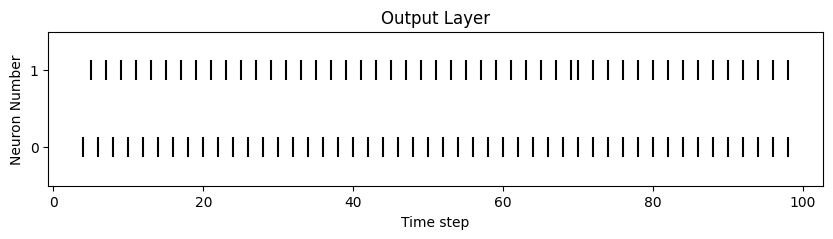

In [13]:
fig = plt.figure(facecolor="w", figsize=(10, 2))
ax = fig.add_subplot(111)

#  s: size of scatter points; c: color of scatter points
splt.raster(spk_rec, ax, s=200, c="black", marker='|')
plt.yticks([0, 1], ['0', '1'])
ax.set_ylim(-0.5, 1.5)
plt.title("Output Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

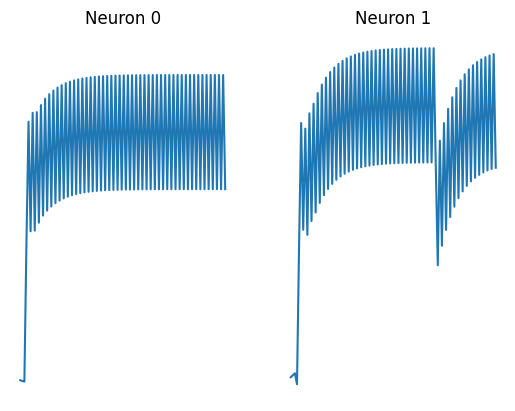

In [14]:
splt.traces(mem_rec, dim=(1, 2), titles=['Neuron 0', 'Neuron 1'])

### Final Decision

Here we can save our weight parameters to be loaded in

In [15]:
model_weights = snn.state_dict()

weights_file_path = 'model_weights/snn_weights.pth'

torch.save(model_weights, weights_file_path)